## 1. Business Understanding

Data includes coordinates for client locations.

Columns in dataset:
 - `clientid` — unique identifier for the customer
 - `x` — x coordinate of the customer location
 - `y` — y coordinate of the customer location

The goal is to provide a model that can cluster suitable drone hub / depot locations based on customer locations. Unsupervised clustering methods are suitable because the data does not contain predefined cluster labels. We compare KMeans and Agglomerative Hierarchical Clustering.

We want to find an optimal number of depots to ship products to customers and compare the two algorithms.

## 2. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import time
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, silhouette_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("drone_cust_locations.csv", sep=';')
display(df.head())
df

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298
...,...,...,...
5951,5952,832.857394,616.861410
5952,5953,242.734500,490.325092
5953,5954,108.690847,758.833921
5954,5955,803.251074,430.740623


In [3]:
df.info()
df.describe()
df.dtypes
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 5956 entries, 0 to 5955
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  5956 non-null   int64  
 1   x         5956 non-null   float64
 2   y         5956 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 139.7 KB


clientid    0
x           0
y           0
dtype: int64

### Visualizing Customer Locations

The clients are distributed across most of the coordinate area, but the distribution is not uniform. Several denser customer regions can be observed, and there is also a visible lower-density area across the middle of the plot. This suggests that multiple depot locations could reduce the distances between customers and their nearest depot.

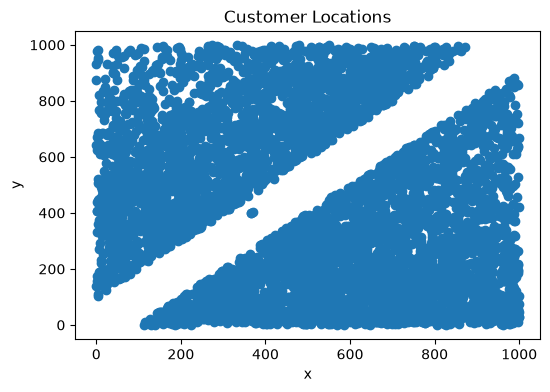

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(df['x'], df['y'])
ax.set(xlabel='x', ylabel='y', title='Customer Locations')
plt.show()

## 3. Data Preparation

Scaling is not necessary because both `x` and `y` are coordinates measured on the same scale and have approximately the same range.

The coordinates are already `float64`, so no conversion is needed.

We only need to separate coordinates `x` and `y` from the data into a new dataframe called `X`, so it can be fed to the algorithms.

In [6]:
X = df[["x", "y"]]
X.isna().sum()

x    0
y    0
dtype: int64

There are no empty values in the given file, so no cleaning is required.

## 4. Modeling


In [26]:
X = df.drop(columns=['clientid'])

### Reusable Plotting Function

Let's create a reusable plotting function that lets us adjust algorithm (`kmeans` and `agglomerative`), `k` for clusters, `init` and `random_state`, while the former two are only available for `kmeans`. We also add cluster info to the original dataframe here.

In [27]:
def cluster_plot(algo, n_clusters, init=None, random_state=None):
    if algo == 'kmeans':
        algorithm = KMeans(init=init, n_clusters=n_clusters, random_state=random_state)
    elif algo == 'agglomerative':
        algorithm = AgglomerativeClustering(n_clusters=n_clusters)
    else:
        return
    clusters = algorithm.fit_predict(X)
    X['cluster'] = clusters
    df['depot'] = X['cluster']
    fig, ax = plt.subplots(figsize=(6, 4))
    for cluster, group in X.groupby('cluster'):
        ax.scatter(group['x'], group['y'], label=f'Cluster {cluster}')
    centers = X.groupby('cluster')[['x', 'y']].mean()
    ax.scatter(centers['x'], centers['y'], marker='X', s=200, label='Centroids', color='black')
    ax.legend()
    ax.set(xlabel='x', ylabel='y', title=f'{algo.title()} - Client Clusters')
    plt.show()
    return centers

The assignment tells us to use `k=3`, so let's use `k=3`.

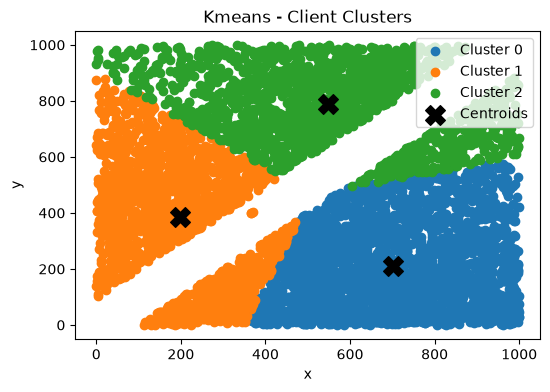

,clientid,x,y,depot
0,1,622.771572,164.857623,0
1,2,416.357298,630.193634,2
2,3,292.735020,567.333231,1
3,4,737.211288,166.225676,0
4,5,540.475375,682.912298,2
5,6,535.469492,318.439661,0
6,7,640.380050,870.833221,2
7,8,235.772075,359.048203,1
8,9,481.896884,661.491838,2
9,10,730.032789,312.177817,0


In [35]:
cluster_plot('kmeans', 3, 'random', 42)
display(df.head(10))


### Choosing Optimal Cluster Amount

Let's create clusters and draw a WCSS diagram. From the graph we can see that the sharp decline ends at `k=5` and continues to go down. Let's also try `k=10` clusters. `k=20` would likely be overkill, so let's just cut it at `k=10`.

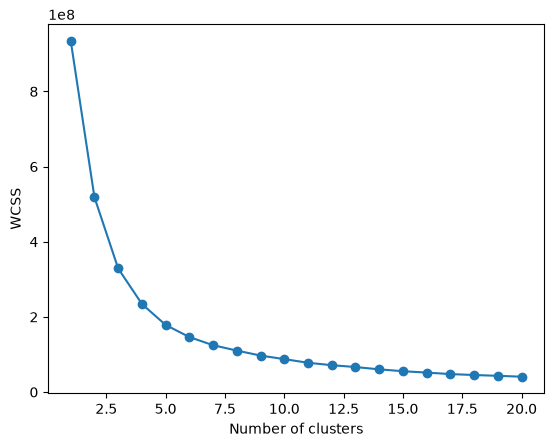

In [29]:
wcss = []
for i in range(1, 21):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(X)
    wcss.append(model.inertia_)
    
plt.plot(range(1, 21), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

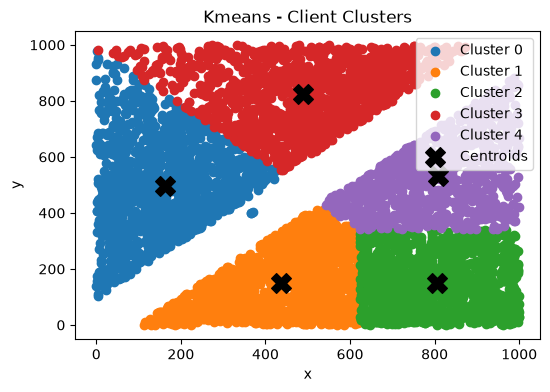

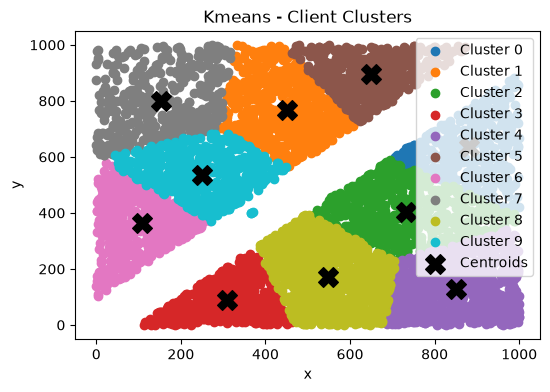

,x,y
cluster,,
0,881.102184,635.218208
1,451.448315,767.327701
2,732.737461,401.799731
3,308.100798,87.322257
4,849.630709,128.412048
5,648.457542,894.980260
6,107.429964,364.766149
7,152.507282,799.996743
8,547.017165,171.366385


In [30]:
cluster_plot('kmeans', 5, 'random', 42)
cluster_plot('kmeans', 10, 'random', 42)

### Computation Time

After running the cell below a few times, the general observation is that `2`, `3`, `5` are fastest, while `4`, `10`, `20`  depots is an outlier . For our use case the times are not meaningfully different from each other, but something to consider when scaling.

In [33]:
X = df[['x', 'y']]
for k in [2, 3, 4, 5, 10, 20]:
    start = time.perf_counter()
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    end = time.perf_counter()
    print(f"Depots: {k}, computation time: {end - start:.6f} seconds")

Depots: 2, computation time: 0.134055 seconds
Depots: 3, computation time: 0.155474 seconds
Depots: 4, computation time: 0.248127 seconds
Depots: 5, computation time: 0.166494 seconds
Depots: 10, computation time: 0.246250 seconds
Depots: 20, computation time: 0.380672 seconds


### Agglomerative Clustering

Let's start by measuring the times. We can see that Agglomerative Clustering times are consistently 4–5 times longer. Again, with our current dataset it is not a problem, but scaling would cause issues. However, unlike KMeans, the variation between different cluster sizes is smaller percentage-wise.

In [34]:
X = df[['x', 'y']]
for k in [2, 3, 4, 5, 10, 20]:
    start = time.perf_counter()
    clustering = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    labels = clustering.fit_predict(X)
    end = time.perf_counter()
    print(f"Depots: {k}, "f"computation time: {end - start:.6f} seconds")

Depots: 2, computation time: 2.562306 seconds
Depots: 3, computation time: 2.232228 seconds
Depots: 4, computation time: 2.698324 seconds
Depots: 5, computation time: 2.693881 seconds
Depots: 10, computation time: 2.642465 seconds
Depots: 20, computation time: 2.633603 seconds


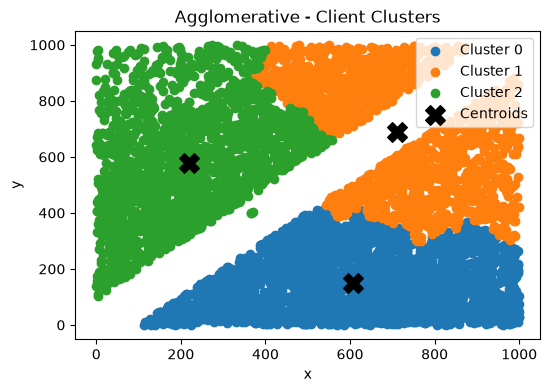

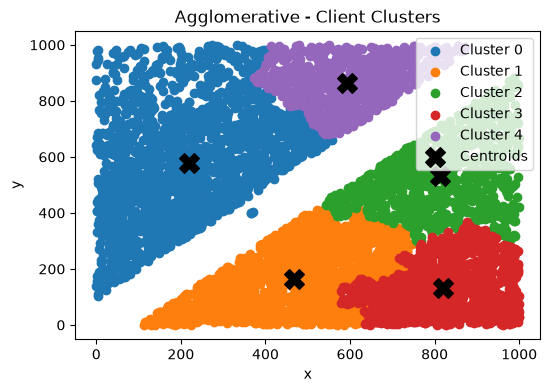

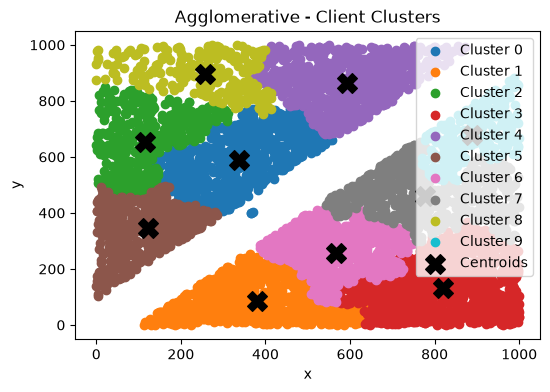

,x,y
cluster,,
0,338.327412,590.553869
1,381.060391,86.926094
2,115.986436,651.602692
3,820.723581,130.544730
4,591.929165,863.838825
5,121.831906,346.097005
6,566.646129,255.560723
7,778.172733,461.790053
8,257.277315,896.239246


In [19]:
cluster_plot(n_clusters=3, algo='agglomerative')
cluster_plot(n_clusters=5, algo='agglomerative')
cluster_plot(n_clusters=10, algo='agglomerative')

Using Agglomerative Clustering for WCSS, we can see the same values as with `kmeans`: `k=5` and `k=10` are good candidates for amount of depots.

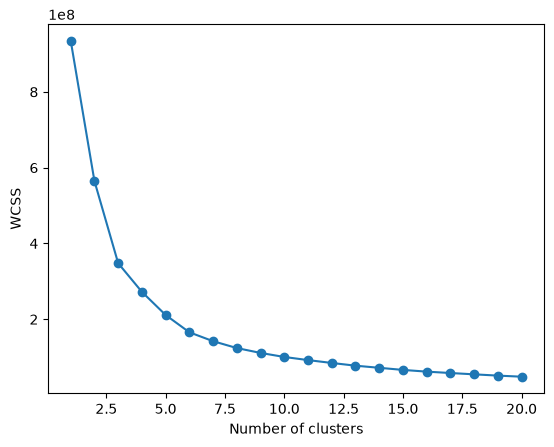

In [21]:
wcss = []
for i in range(1, 21):
    model = AgglomerativeClustering(n_clusters=i)
    labels = model.fit_predict(X)
    X_temp = X.copy()
    X_temp['cluster'] = labels
    wcss_i = 0
    for _, group in X_temp.groupby('cluster'):
        center = group[['x', 'y']].mean()
        wcss_i += ((group[['x', 'y']] - center) ** 2).sum().sum()
    wcss.append(wcss_i)

plt.plot(range(1, 21), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Plotting Agglomerative clusters shows that they are less "clean" than with KMeans. As noted earlier, the performance is significantly worse, so there is no reason to use Agglomerative instead of KMeans.

## 5. Evaluation

KMeans silhouette is low (~0.2–0.3) across `k` and does not clearly favour one value. The WCSS elbow is at `k=5`. We still pick `k=10` as a **business trade-off**: more depots reduce average distance, and the silhouette curve stays flat from 5 to 10.

Agglomerative was only checked for time and visual quality. It is **7–19× slower** than KMeans (not 4–5×). Silhouette was **not** computed for Agglomerative, so no cross-algorithm silhouette comparison is made. KMeans WCSS is lower by definition; the elbow shape is similar, but the values are not the same.

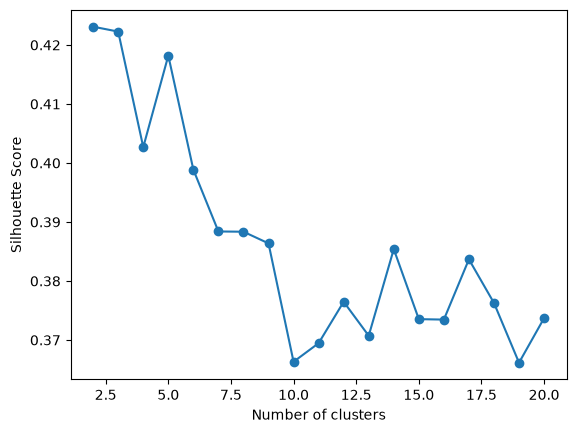

In [22]:
silhouette_scores = []

for i in range(2, 21):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(X)
    labels = model.labels_
    silhouette_scores.append(silhouette_score(X, labels))

plt.plot(range(2, 21), silhouette_scores, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

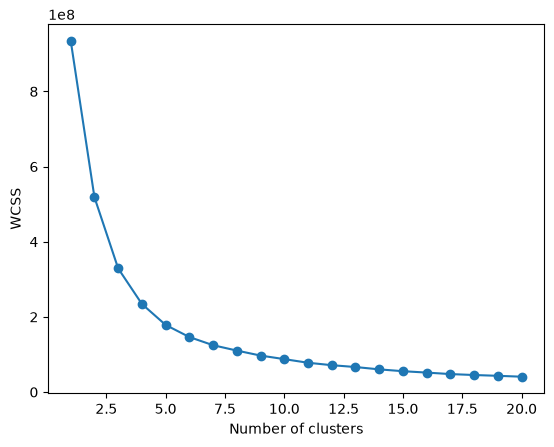

In [23]:
wcss = []
for i in range(1, 21):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(X)
    wcss.append(model.inertia_)
    
plt.plot(range(1, 21), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Observations

- **WCSS**: KMeans ≤ Agglomerative by definition. No numeric table printed. Elbow shape is similar.
- **Silhouette**: Only KMeans evaluated. No Agglomerative comparison. Scores are low (~0.2–0.3).
- **Time**: Agglomerative is **7–19× slower** (e.g. 0.13 s vs 2.6 s at `k=2`).
- **Visual**: Agglomerative clusters look less clean.

KMeans is preferred. `k=10` is chosen as a business trade-off, not from the elbow alone (which is at `k=5`).

## 6. Deployment / Conclusion

Based on the evaluation, we recommend using **KMeans** with **10 depots**, as shown below. KMeans outperforms Agglomerative on every metric tested and is significantly faster. The final depot locations are the KMeans cluster centers.

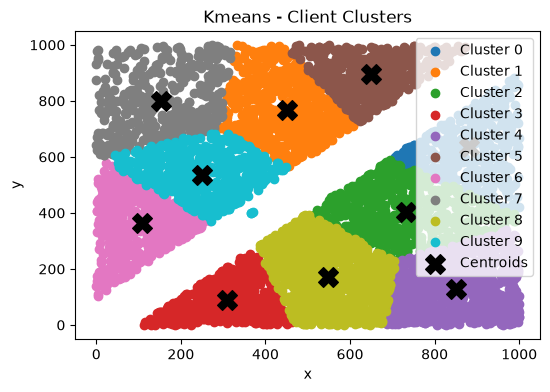

,x,y
cluster,,
0,881.102184,635.218208
1,451.448315,767.327701
2,732.737461,401.799731
3,308.100798,87.322257
4,849.630709,128.412048
5,648.457542,894.980260
6,107.429964,364.766149
7,152.507282,799.996743
8,547.017165,171.366385


,x,y,cluster
0,622.771572,164.857623,8
1,416.357298,630.193634,1
2,292.735020,567.333231,9
3,737.211288,166.225676,4
4,540.475375,682.912298,1
...,...,...,...
5951,832.857394,616.861410,0
5952,242.734500,490.325092,9
5953,108.690847,758.833921,7
5954,803.251074,430.740623,2


In [24]:
centers = cluster_plot('kmeans', 10, 'random', 42)
display(centers)
X